# MNIST Feature Preparation Workflow

This notebook shows the exact data-prep flow before training classical ML models.

In [7]:
from pathlib import Path
import numpy as np
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
RANDOM_STATE = 42
data_path = '../../data/mnist.npz'

data = np.load(data_path)
x_all = np.concatenate([data['x_train'], data['x_test']], axis=0)
y_all = np.concatenate([data['y_train'], data['y_test']], axis=0)

print('All images shape:', x_all.shape)
print('All labels shape:', y_all.shape)

All images shape: (70000, 28, 28)
All labels shape: (70000,)


## Phase 1 Example: Binary 0 vs 1

In [17]:
class_a, class_b = 0, 1
mask = (y_all == class_a) | (y_all == class_b)
x = x_all[mask]
y = y_all[mask]

print('Binary shapes:', x.shape, y.shape)
print('Counts:', dict(zip(*np.unique(y, return_counts=True))))

Binary shapes: (14780, 28, 28) (14780,)
Counts: {0: 6903, 1: 7877}


In [18]:
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

val_relative = 0.2 / (1.0 - 0.2)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=val_relative, random_state=RANDOM_STATE, stratify=y_train_val
)

print('Train:', x_train.shape, y_train.shape)
print('Val  :', x_val.shape, y_val.shape)
print('Test :', x_test.shape, y_test.shape)

Train: (8868, 28, 28) (8868,)
Val  : (2956, 28, 28) (2956,)
Test : (2956, 28, 28) (2956,)


In [11]:
# Normalize pixel range to [0, 1]
x_train = x_train.astype(np.float32) / 255.0
x_val = x_val.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

print('Train min/max:', x_train.min(), x_train.max())

Train min/max: 0.0 1.0


## Feature Mode 1: Flatten

In [12]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_val_flat = x_val.reshape(x_val.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

scaler_flat = StandardScaler()
x_train_flat = scaler_flat.fit_transform(x_train_flat)
x_val_flat = scaler_flat.transform(x_val_flat)
x_test_flat = scaler_flat.transform(x_test_flat)

print('Flatten train shape:', x_train_flat.shape)

Flatten train shape: (8868, 784)


## Feature Mode 2: PCA

In [13]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
x_train_pca = pca.fit_transform(x_train_flat)
x_val_pca = pca.transform(x_val_flat)
x_test_pca = pca.transform(x_test_flat)

print('PCA components retained:', pca.n_components_)
print('PCA train shape:', x_train_pca.shape)

PCA components retained: 194
PCA train shape: (8868, 194)


## Feature Mode 3: HOG

In [14]:
def extract_hog_batch(images):
    feats = []
    for img in images:
        feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True,
        )
        feats.append(feat)
    return np.asarray(feats)

x_train_hog = extract_hog_batch(x_train)
x_val_hog = extract_hog_batch(x_val)
x_test_hog = extract_hog_batch(x_test)

scaler_hog = StandardScaler()
x_train_hog = scaler_hog.fit_transform(x_train_hog)
x_val_hog = scaler_hog.transform(x_val_hog)
x_test_hog = scaler_hog.transform(x_test_hog)

print('HOG train shape:', x_train_hog.shape)

HOG train shape: (8868, 1296)


Now you can feed any prepared feature set into KNN, Logistic Regression, SVM, Naive Bayes, or Decision Tree.

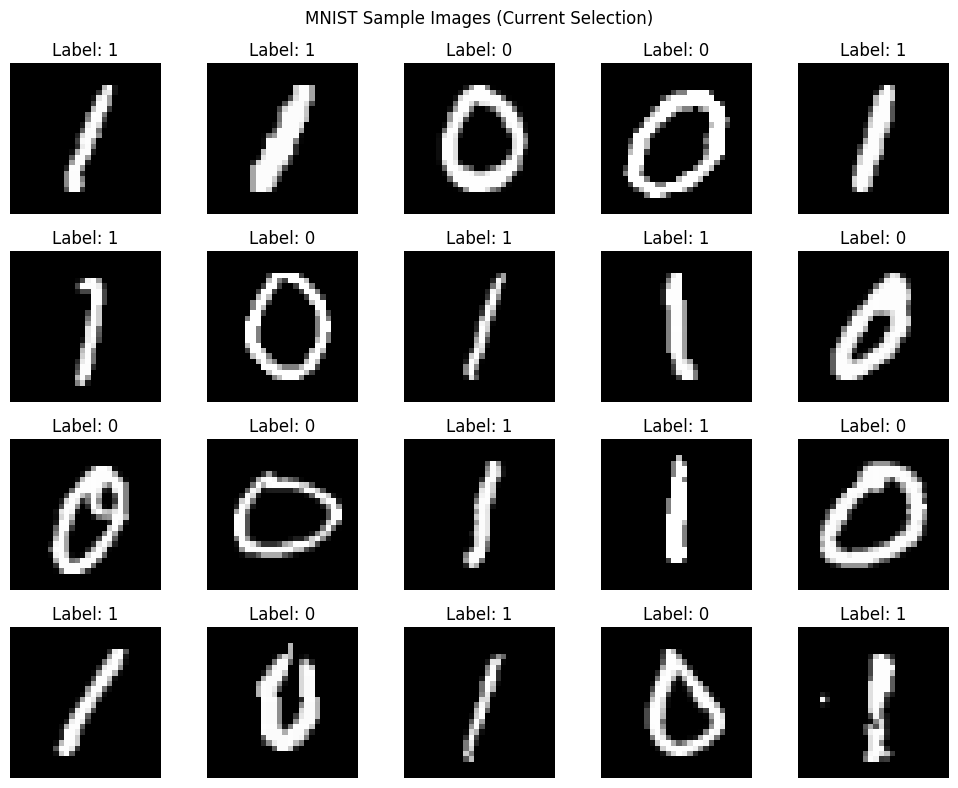

In [16]:
# Visualize 20 random images from the selected binary dataset
import matplotlib.pyplot as plt

num_images = 20
indices = np.random.choice(len(x), size=num_images, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.ravel()

for i, idx in enumerate(indices):
    axes[i].imshow(x[idx], cmap='gray')
    axes[i].set_title(f"Label: {y[idx]}")
    axes[i].axis('off')

plt.suptitle('MNIST Sample Images (Current Selection)')
plt.tight_layout()
plt.show()